<a href="https://colab.research.google.com/github/Meghana-Komali/zomato-task/blob/main/zomato.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
df = pd.read_csv('/content/zomato.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

In [ ]:
df.head()


,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [ ]:
df.tail()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
56247,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,080 40301477,Whitefield,Bar,NaN,Continental,"1,500",Pubs and bars
56248,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,+91 8197675843,Whitefield,Bar,NaN,Finger Food,600,Pubs and bars
56249,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,NaN,Finger Food,"2,000",Pubs and bars
56250,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,080 49652769,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500",Pubs and bars
56251,"ITPL Main Road, KIADB Export Promotion Industr...",The Nest - The Den Bengaluru,No,No,3.4 /5,13,+91 8071117272,"ITPL Main Road, Whitefield","Bar, Casual Dining",NaN,"Finger Food, North Indian, Continental","1,500",Pubs and bars


In [ ]:
df['rate'] = df['rate'].astype(str).str.replace('/5', '', regex=False)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   address                      56235 non-null  object 
 1   name                         56236 non-null  object 
 2   online_order                 56233 non-null  object 
 3   book_table                   56194 non-null  object 
 4   rate                         41665 non-null  float64
 5   votes                        56174 non-null  object 
 6   phone                        54956 non-null  object 
 7   location                     56126 non-null  object 
 8   rest_type                    55914 non-null  object 
 9   dish_liked                   28027 non-null  object 
 10  cuisines                     56049 non-null  object 
 11  approx_cost(for two people)  55731 non-null  object 
 12  listed_in(type)              51642 non-null  object 
dtypes: float64(1), o

In [ ]:
df['cost'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   address                      56235 non-null  object 
 1   name                         56236 non-null  object 
 2   online_order                 56233 non-null  object 
 3   book_table                   56194 non-null  object 
 4   rate                         41665 non-null  float64
 5   votes                        56174 non-null  object 
 6   phone                        54956 non-null  object 
 7   location                     56126 non-null  object 
 8   rest_type                    55914 non-null  object 
 9   dish_liked                   28027 non-null  object 
 10  cuisines                     56049 non-null  object 
 11  approx_cost(for two people)  55731 non-null  object 
 12  listed_in(type)              51642 non-null  object 
 13  cost            

In [ ]:
df.dropna(subset=['rate','cost','cuisines'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34756 entries, 0 to 56246
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   address                      34756 non-null  object 
 1   name                         34756 non-null  object 
 2   online_order                 34756 non-null  object 
 3   book_table                   34756 non-null  object 
 4   rate                         34756 non-null  float64
 5   votes                        34756 non-null  object 
 6   phone                        34212 non-null  object 
 7   location                     34756 non-null  object 
 8   rest_type                    34613 non-null  object 
 9   dish_liked                   17375 non-null  object 
 10  cuisines                     34756 non-null  object 
 11  approx_cost(for two people)  34756 non-null  object 
 12  listed_in(type)              32298 non-null  object 
 13  cost                 

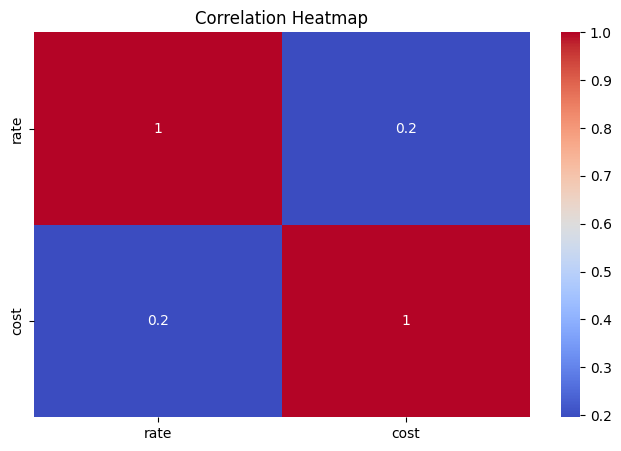

In [ ]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

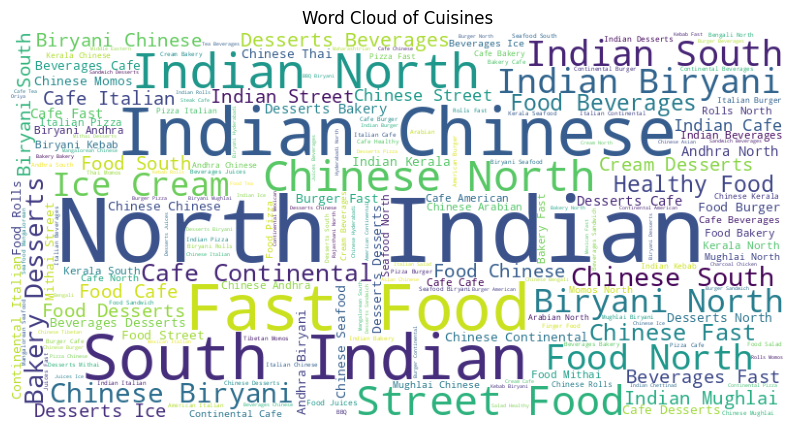

In [ ]:
text = " ".join(df['cuisines'].dropna())
wc = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 6))
plt.imshow(wc)
plt.axis('off')
plt.title('Word Cloud of Cuisines')
plt.show()

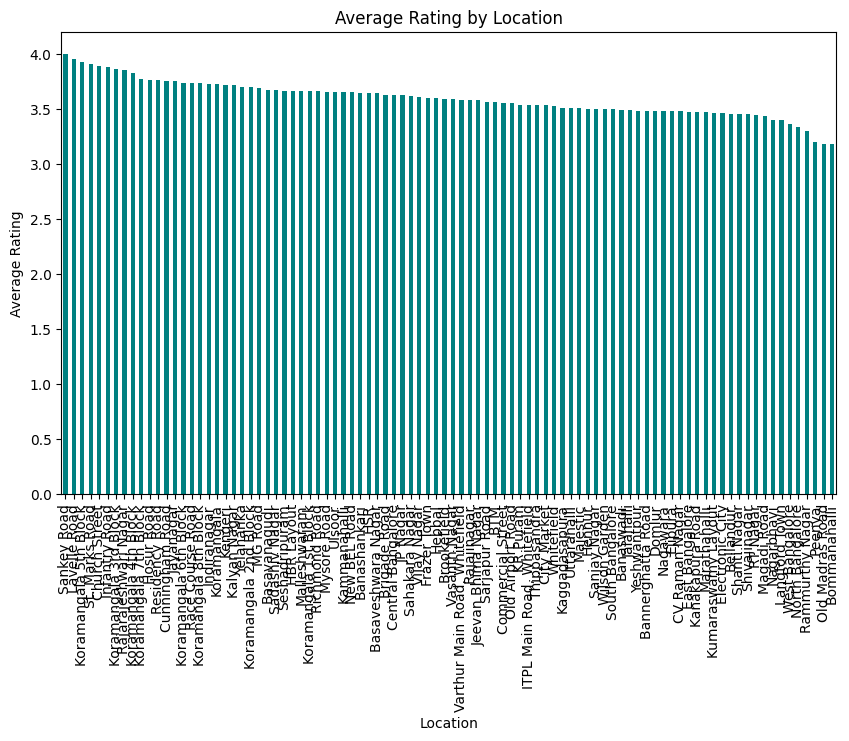

In [ ]:
plt.figure(figsize=(10, 6))
df.groupby('location')['rate'].mean().sort_values(ascending=False).plot(kind='bar', color='teal')
plt.title('Average Rating by Location')
plt.xlabel('Location')
plt.ylabel('Average Rating')
plt.show()

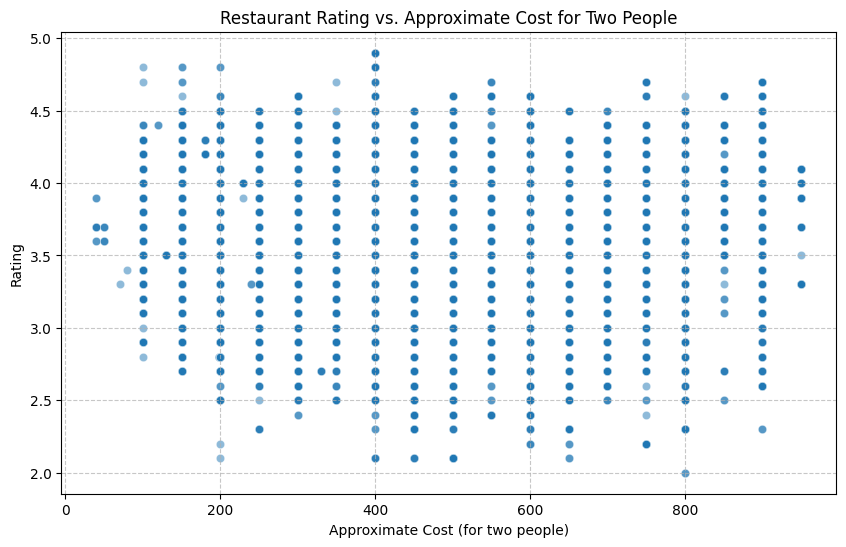

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='cost', y='rate', data=df, alpha=0.5)
plt.title('Restaurant Rating vs. Approximate Cost for Two People')
plt.xlabel('Approximate Cost (for two people)')
plt.ylabel('Rating')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()